In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pickle
import scipy.special
import scipy.integrate


import pyccl as ccl
import HOD
import sys, os
sys.path.append('/projects/bdne/spandey3/BaryonForge')
import BaryonForge as bfg
import BaryonForge.Profiles



## Setup the parameters for baryonforge
### **Careful of the units of h in all the parameters as well, especially the ones that define the masses!**


In [2]:
cosmo = ccl.Cosmology(Omega_c = 0.3 - 0.048 , Omega_b = 0.048, h=0.672, sigma8=0.8, n_s=0.96,
                      matter_power_spectrum='linear')
h = cosmo['h']

par = dict(theta_ej = 2, theta_co = 0.05, mu_beta = 0.0762,
               nu_theta_ej=-1.22, mu_theta_ej=-0.33, M_c= (10**13.75)/h, M_theta_ej=1e16/h,M_theta_co=1e16/h,
                eta = 0.3, eta_delta = 0.3, tau = -1.5, tau_delta = 0, #Must use tau here since we go down to low mass
                A = 0.09/2, M1 = 2.5e11, epsilon_h = 0.015, 
                a = 0.3, n = 2, epsilon = 4, p = 0.3, q = 0.707, gamma = 2, delta = 7,
                alpha_nt=0.2, nu_nt=0.5, gamma_nt=0.3, #nu_M_c=0.2,
               N_sfr = 1.5, eps_sfr=0.4, r_line=1.2)
Mstar_th = 1e12 # In Msun units



## Calculate the profiles
### **Careful of the integration resolution. Baryonforge does the integral directly in the r-space for Mtot etc, so needs a very high resolution grid**


In [3]:
mdef = ccl.halos.massdef.MassDef200c
concentration = ccl.halos.concentration.ConcentrationDuffy08(mass_def=mdef)
DMO = bfg.Profiles.Schneider19.DarkMatter(c_M_relation=ccl.halos.concentration.ConcentrationDuffy08, 
                                          epsilon = 4, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 2000)
M_2_Mtot = bfg.Profiles.misc.Mdelta_to_Mtot(DMO, r_min = 1e-5, r_max = 8, N_int = 8000)


HOD_fractions = HOD.BaryonifiedHODFractions(M_2_Mtot=M_2_Mtot, Mstar_th=Mstar_th)
CGA = HOD.Stars(**par, fractions=HOD_fractions, r_min_int = 5e-3, r_max_int = 8, r_steps = 2000)
SGA = HOD.SatelliteStars(stars=CGA, **par, r_min_int = 5e-3, r_max_int = 8, r_steps = 2000)

self = HOD.BaryonifiedHOD(mass_def=mdef, concentration=concentration, CGA=CGA, SGA=SGA)


hmf = ccl.halos.MassFuncTinker10(mass_def=mdef)
bM = ccl.halos.HaloBiasTinker10(mass_def=mdef)

HMC = bfg.utils.FlexibleHMCalculator(mass_function = hmf, halo_bias = bM, halo_m_to_mtot = M_2_Mtot,
                                  mass_def = mdef,
                                  log10M_min = 11.5, log10M_max = 15.5, nM = 20)


                                  

In [4]:
fft_precision = dict(padding_lo_fftlog = 1e-8, padding_hi_fftlog = 1e8, n_per_decade = 20)
self.update_precision_fftlog(**fft_precision)
self.SGA.update_precision_fftlog(**fft_precision)
a = 1


In [5]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update("jax_enable_x64", True)
import jax
import matplotlib
import matplotlib.pyplot as pl
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
pl.rc('text', usetex=True)





/tmp/ipykernel_3839837/2818056999.py:5: DeprecationWarning: jax.lib.xla_bridge module will be removed in JAX v0.9.0; all its APIs were deprecated and removed by JAX v0.8.0.
  from jax.lib import xla_bridge


1 1


In [6]:
import yaml
import pathlib
from deepmerge import always_merger
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 


# Load the parameters into a dictionary:
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/Pge/params_code_comp.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# Load the n(z) for the lens catalogs. 
# This is for spectroscopic survey. So there is comoving n(z) provided
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving



from scipy.interpolate import interp1d
# ks = np.geomspace(5e-2,50,15) # wavenumbers
ks = np.geomspace(3e-1,10,10) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

# This is the actual n(z) from the comoving n(z):
nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict



/tmp/ipykernel_3839837/1363698662.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_3839837/1363698662.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


In [7]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
import matplotlib.pyplot as pl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)




In [8]:
M_array = base_test.M_array
z_array = base_test.z_array
r_array = base_test.r_array
k_array = base_test.kPk_array
ell_array = base_test.ell_array


In [9]:
indM = 12
indz = 3
rho_dmo_bfg = self.SGA.DarkMatter.real(cosmo, r_array/h, float(M_array[indM]/h), float(1/(1+z_array[indz])))/h**2
rho_dmo_jax = profiles_test.rho_nfw_mat[:, indz, indM]





In [10]:
rho_clm_bfg = self.SGA._real(cosmo, r_array/h, float(M_array[indM]/h), float(1/(1+z_array[indz])))/h**2

# For some reason the baryonforge code is dividing the density by fclm, so do the same here:
rho_clm_jax = profiles_test.rho_clm_mat[:, indz, indM]/profiles_test.fclm_mat[indz, indM]



/projects/bdne/spandey3/map_godmax/GODMAX/notebooks/Pge/HOD.py:93: RuntimeWarning: overflow encountered in power
  return 10**log10_inv_fSHMR
/projects/bdne/spandey3/map_godmax/GODMAX/notebooks/Pge/HOD.py:455: UserWarning: Increase integral upper limit, r_max_int (8) < maximum radius (23.809523809523807)
  warnings.warn(f"Increase integral upper limit, r_max_int ({self.r_max_int}) < maximum radius ({np.max(r)})", UserWarning)


In [11]:
f_gas_bfg = self.SGA.Gas._get_gas_frac(M_array[indM]/h, 1/(1+z_array[indz]), cosmo)
f_gas_jax = profiles_test.fgas_mat[indz, indM]

rho_gas_bfg = (self.SGA.Gas.real(cosmo, r_array/h, float(M_array[indM]/h), float(1/(1+z_array[indz])))/h**2)/f_gas_bfg
rho_gas_jax = profiles_test.rho_gas_mat[:, indz, indM]/f_gas_jax

print(f_gas_bfg, f_gas_jax)


0.1423914347840684 0.1546211202097095


In [12]:
f_cga_bfg  = self.fractions._fc(float(M_array[indM]/h), float(1/(1+z_array[indz])), cosmo=cosmo)
f_cga_jax = profiles_test.fstar_cen_mat[indz, indM]


rho_cga_bfg = (self.CGA.real(cosmo, r_array/h, float(M_array[indM]/h), float(1/(1+z_array[indz])))/h**2)/f_cga_bfg
rho_cga_jax = profiles_test.rho_cga_mat[:, indz, indM]/f_cga_jax

print(f_cga_bfg, f_cga_jax)





[[0.0025671]] 0.003004424093601604


Text(0.5, 1.0, 'DMO profile, logM=13.6, z=0.2')

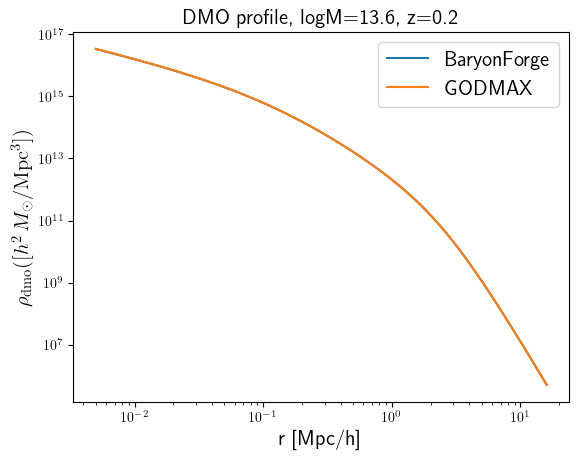

In [13]:
pl.figure()
pl.plot(r_array, rho_dmo_bfg, label='BaryonForge')
pl.plot(r_array, rho_dmo_jax, label='GODMAX')
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel('r [Mpc/h]', fontsize=15)
pl.ylabel(r'$\rho_{\rm dmo}([h^2 \, M_{\odot}/\textrm{Mpc}^3])$', fontsize=15)
pl.title(f'DMO profile, logM={np.log10(M_array[indM]):.1f}, z={z_array[indz]:.1f}', fontsize=15)



Text(0.5, 1.0, 'CLM profile, logM=13.6, z=0.2')

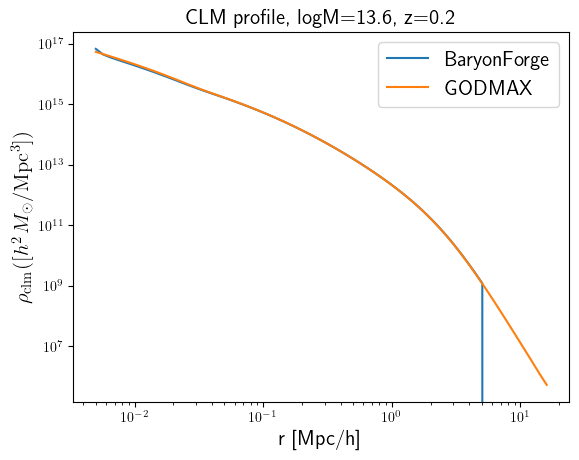

In [14]:
pl.figure()
pl.plot(r_array, rho_clm_bfg, label='BaryonForge')
pl.plot(r_array, rho_clm_jax, label='GODMAX')
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel('r [Mpc/h]', fontsize=15)
pl.ylabel(r'$\rho_{\rm clm}([h^2 \, M_{\odot}/\textrm{Mpc}^3])$', fontsize=15)
pl.title(f'CLM profile, logM={np.log10(M_array[indM]):.1f}, z={z_array[indz]:.1f}', fontsize=15)


Text(0.5, 1.0, 'GAS profile, logM=13.6, z=0.2')

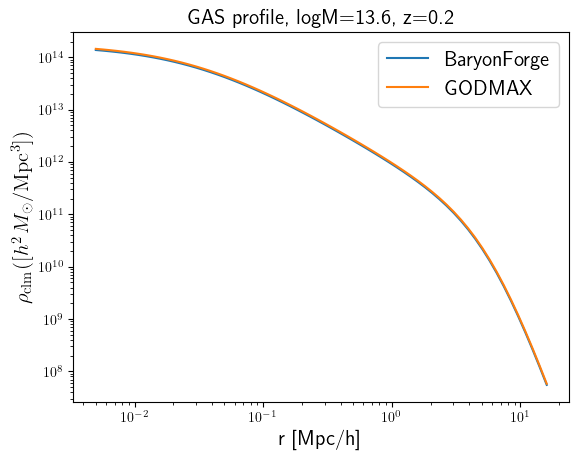

In [15]:
pl.figure()
pl.plot(r_array, rho_gas_bfg, label='BaryonForge')
pl.plot(r_array, rho_gas_jax, label='GODMAX')
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel('r [Mpc/h]', fontsize=15)
pl.ylabel(r'$\rho_{\rm clm}([h^2 \, M_{\odot}/\textrm{Mpc}^3])$', fontsize=15)
pl.title(f'GAS profile, logM={np.log10(M_array[indM]):.1f}, z={z_array[indz]:.1f}', fontsize=15)



Text(0.5, 1.0, 'CGA profile, logM=13.6, z=0.2')

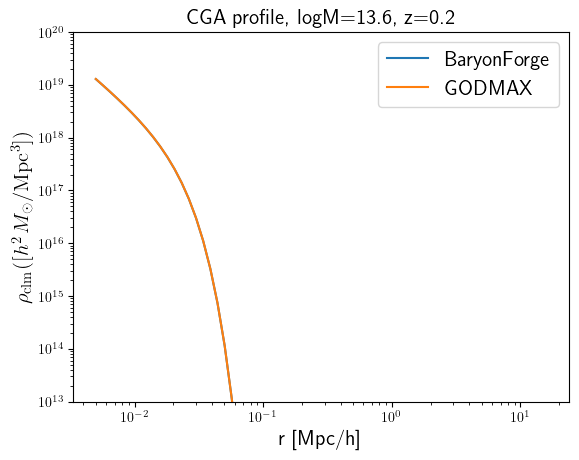

In [16]:
pl.figure()
pl.plot(r_array, rho_cga_bfg[0,:], label='BaryonForge')
pl.plot(r_array, rho_cga_jax, label='GODMAX')
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e13, 1e20)
pl.legend(fontsize=15)
pl.xlabel('r [Mpc/h]', fontsize=15)
pl.ylabel(r'$\rho_{\rm clm}([h^2 \, M_{\odot}/\textrm{Mpc}^3])$', fontsize=15)
pl.title(f'CGA profile, logM={np.log10(M_array[indM]):.1f}, z={z_array[indz]:.1f}', fontsize=15)




Text(0.5, 1.0, 'Ratio profiles, logM=13.6, z=0.2')

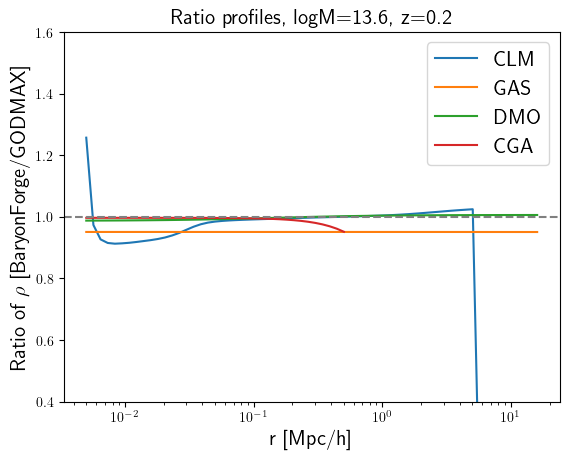

In [17]:
pl.figure()
pl.plot(r_array, rho_clm_bfg/rho_clm_jax, label='CLM')
pl.plot(r_array, rho_gas_bfg/rho_gas_jax, label='GAS')
pl.plot(r_array, rho_dmo_bfg/rho_dmo_jax, label='DMO')
pl.plot(r_array, rho_cga_bfg[0,:]/rho_cga_jax, label='CGA')
# pl.plot(r_array, rho_clm_jax, label='GODMAX')
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.4, 1.6)
pl.axhline(1, c='grey', ls='--')
pl.legend(fontsize=15)
pl.xlabel('r [Mpc/h]', fontsize=15)
pl.ylabel(r'Ratio of $\rho$ [BaryonForge/GODMAX]', fontsize=15)
pl.title(f'Ratio profiles, logM={np.log10(M_array[indM]):.1f}, z={z_array[indz]:.1f}', fontsize=15)




In [118]:
indz = 1
from colossus.cosmology import cosmology
from colossus.lss import mass_function

params = {'flat': True, 'H0': 67.2, 'Om0': 0.3, 'Ob0': 0.048, 'sigma8': 0.8, 'ns': 0.96}
h = params['H0']/100.
cosmology.addCosmology('myCosmo', **params)
cosmo_colossus = cosmology.setCosmology('myCosmo')

mfunc_dndlnM_colossus = mass_function.massFunction(M_array, z_array[indz], mdef = '200c', model = 'tinker08', q_out = 'dndlnM')

cosmo = ccl.Cosmology(Omega_c = 0.3 - 0.048 , Omega_b = 0.048, h=0.672, sigma8=0.8, n_s=0.96,
                      matter_power_spectrum='linear')

hmd_200c = ccl.halos.MassDef200c

mfunc_so_ccl = ccl.halos.MassFuncTinker08(mass_def=hmd_200c)

mfunc_dndlog10M_so_ccl = mfunc_so_ccl(cosmo, (np.array(M_array)/h).astype(float), float(1/(1+z_array[indz])))
mfunc_dndlnM_so_ccl = mfunc_dndlog10M_so_ccl / np.log(10)


Text(0, 0.5, '$\\frac{d n}{d \\ln M}$ $[h^3/\\textrm{Mpc}^3]$')

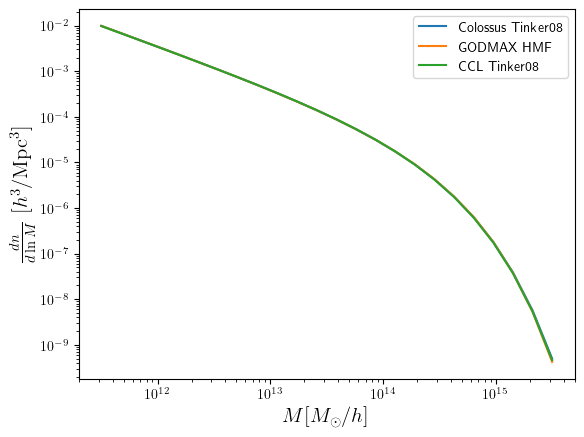

In [119]:
pl.figure()
pl.plot(M_array, mfunc_dndlnM_colossus, label='Colossus Tinker08')
pl.plot(M_array, profiles_test.hmf_Mz_mat[indz, :], label='GODMAX HMF')
pl.plot(M_array, mfunc_dndlnM_so_ccl/(h**3), label='CCL Tinker08')
pl.xscale('log')
pl.yscale('log')
pl.legend()
pl.xlabel(r'$M [M_\odot/h]$', fontsize=15)
pl.ylabel(r'$\frac{d n}{d \ln M}$ $[h^3/\textrm{Mpc}^3]$', fontsize=15)




Text(0, 0.5, 'Ratio of HMFs')

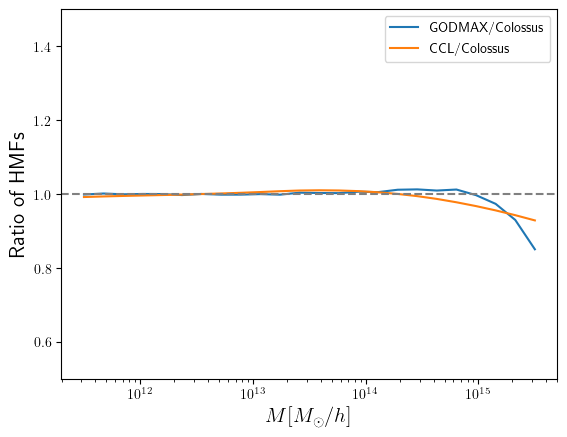

In [120]:
pl.figure()
pl.plot(M_array, profiles_test.hmf_Mz_mat[indz, :]/mfunc_dndlnM_colossus, label='GODMAX/Colossus')
pl.plot(M_array, mfunc_dndlnM_so_ccl/(h**3)/mfunc_dndlnM_colossus, label='CCL/Colossus')
pl.axhline(1, c='grey', ls='--')
pl.xscale('log')
pl.ylim(0.5, 1.5)
pl.legend()
pl.xlabel(r'$M [M_\odot/h]$', fontsize=15)
pl.ylabel('Ratio of HMFs', fontsize=15)
